In [1]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn utilities
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Saving model
import joblib

In [2]:
df=pd.read_csv("algomind_clean_dataset.csv")
df.head()

,uses_array,uses_graph,uses_hashmap,uses_heap,recursion,dynamic_programming,divide_conquer,shortest_path,mst,topological,sorting,search,sliding_window,greedy,backtracking,bitwise,string_problem,algorithm,category
0,1,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,Binary Search,Search
1,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,Binary Search,Search
2,1,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,Binary Search,Search
3,1,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,Binary Search,Search
4,1,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,Binary Search,Search


In [3]:
print(df.shape)

(600, 19)


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   uses_array           600 non-null    int64 
 1   uses_graph           600 non-null    int64 
 2   uses_hashmap         600 non-null    int64 
 3   uses_heap            600 non-null    int64 
 4   recursion            600 non-null    int64 
 5   dynamic_programming  600 non-null    int64 
 6   divide_conquer       600 non-null    int64 
 7   shortest_path        600 non-null    int64 
 8   mst                  600 non-null    int64 
 9   topological          600 non-null    int64 
 10  sorting              600 non-null    int64 
 11  search               600 non-null    int64 
 12  sliding_window       600 non-null    int64 
 13  greedy               600 non-null    int64 
 14  backtracking         600 non-null    int64 
 15  bitwise              600 non-null    int64 
 16  string_p

In [5]:
df.describe()

,uses_array,uses_graph,uses_hashmap,uses_heap,recursion,dynamic_programming,divide_conquer,shortest_path,mst,topological,sorting,search,sliding_window,greedy,backtracking,bitwise,string_problem
count,600.000000,600.00000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.00000,600.000000,600.000000,600.000000,600.000000
mean,0.411667,0.46500,0.186667,0.126667,0.288333,0.033333,0.226667,0.238333,0.175000,0.040000,0.225000,0.115000,0.05500,0.166667,0.175000,0.050000,0.040000
std,0.492546,0.49919,0.389969,0.332877,0.453365,0.179655,0.419024,0.426420,0.380284,0.196123,0.417931,0.319288,0.22817,0.372989,0.380284,0.218127,0.196123
min,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,1.00000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000


In [6]:
print(df['algorithm'].unique())

['Binary Search' 'Two Sum' 'Three Sum' 'DFS' 'BFS' 'Dijkstra'
 'Bellman Ford' 'Floyd Warshall' 'Merge Sort' 'Quick Sort' 'Heap Sort'
 'Kruskal' 'Prim' 'N Queens' 'Sudoku Solver']


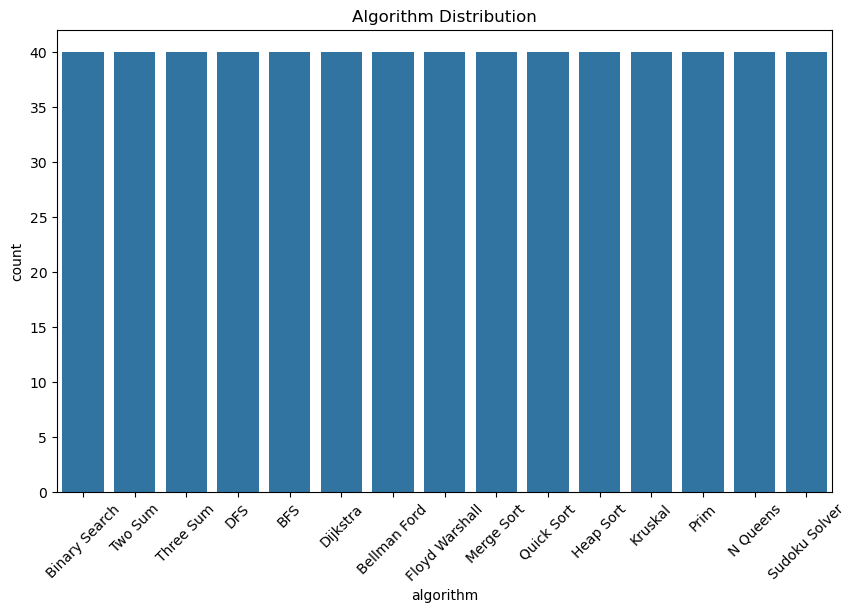

In [7]:
plt.figure(figsize=(10,6))
sns.countplot(x='algorithm', data=df)
plt.xticks(rotation=45)
plt.title("Algorithm Distribution")
plt.show()

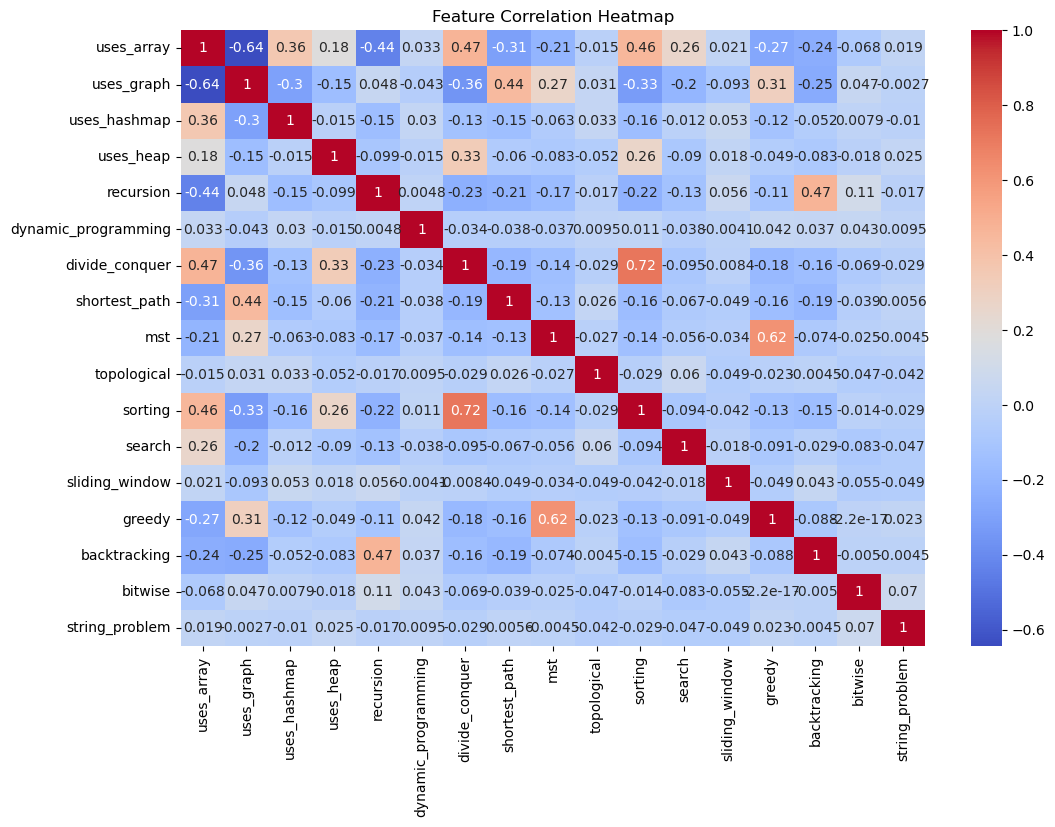

In [8]:
plt.figure(figsize=(12,8))

numeric_df = df.select_dtypes(include=['number'])

sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")

plt.title("Feature Correlation Heatmap")
plt.show()

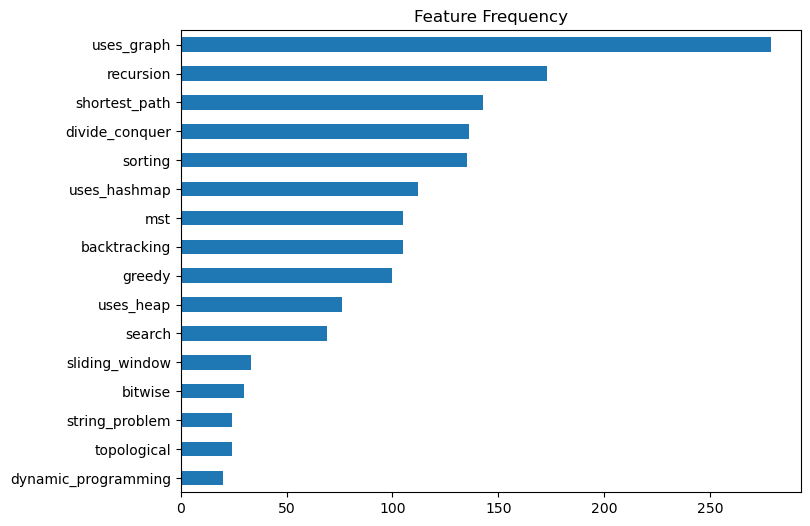

In [9]:
features = df.columns[1:]

numeric_features = df[features].select_dtypes(include=['number'])

numeric_features.sum().sort_values().plot(kind='barh', figsize=(8,6))

plt.title("Feature Frequency")
plt.show()

In [10]:
df.isnull().sum()

uses_array             0
uses_graph             0
uses_hashmap           0
uses_heap              0
recursion              0
dynamic_programming    0
divide_conquer         0
shortest_path          0
mst                    0
topological            0
sorting                0
search                 0
sliding_window         0
greedy                 0
backtracking           0
bitwise                0
string_problem         0
algorithm              0
category               0
dtype: int64

In [11]:
df["graph_problem"] = (
    df["uses_graph"] |
    df["shortest_path"] |
    df["mst"] |
    df["topological"]
).astype(int)

In [12]:
df["optimization_problem"] = (
    df["dynamic_programming"] |
    df["greedy"]
).astype(int)

In [13]:

le = LabelEncoder()

y = le.fit_transform(df["category"])


class_names = list(le.classes_)

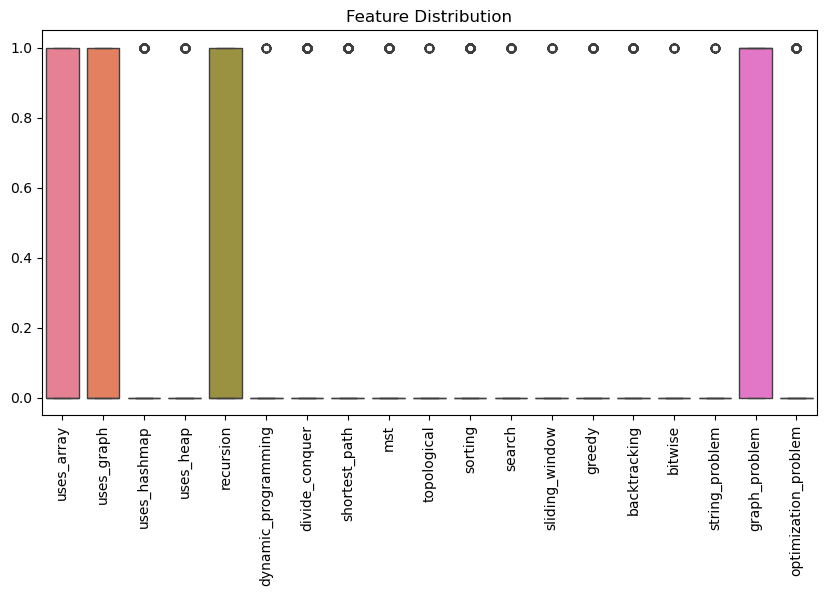

In [14]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df.drop(columns=['algorithm','category']))
plt.xticks(rotation=90)
plt.title("Feature Distribution")
plt.show()

In [15]:
# Select only numeric columns
numeric_df = df.select_dtypes(include=['number'])

# Correlation matrix
corr_matrix = numeric_df.corr().abs()

# Upper triangle matrix
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# Find highly correlated columns
to_drop = [column for column in upper.columns if any(upper[column] > 0.9)]

# Drop them from original dataframe
df.drop(columns=to_drop, inplace=True)

In [16]:
X = df.drop(columns=['algorithm', 'category'])


In [17]:
X

,uses_array,uses_graph,uses_hashmap,uses_heap,recursion,dynamic_programming,divide_conquer,shortest_path,mst,topological,sorting,search,sliding_window,greedy,backtracking,bitwise,string_problem,graph_problem
0,1,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,1
1,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
2,1,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0
4,1,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
595,0,0,1,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0
596,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0
597,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0
598,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0


In [18]:
y

array([4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
       4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
       5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
       5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
       5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
       5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,

In [19]:


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

In [20]:
print(df.shape)
print(df['algorithm'].nunique())

(600, 20)
15


In [21]:
dt_model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=7,
    min_samples_split=12,
    min_samples_leaf=4,
    random_state=42
)

dt_model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=7, min_samples_leaf=4, min_samples_split=12,
                       random_state=42)

In [22]:
y_pred = dt_model.predict(X_test)

In [23]:
import os
import joblib


joblib.dump(X_train, "model/X_train.pkl")
joblib.dump(y_train, "model/y_train.pkl")
# create folder if it doesn't exist
os.makedirs("model", exist_ok=True)

# save encoder
joblib.dump(le, "model/label_encoder.pkl")

# save model
joblib.dump(dt_model, "model/decision_tree.pkl")
joblib.dump(X.columns.tolist(), "model/features.pkl")

['model/features.pkl']

In [24]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8466666666666667


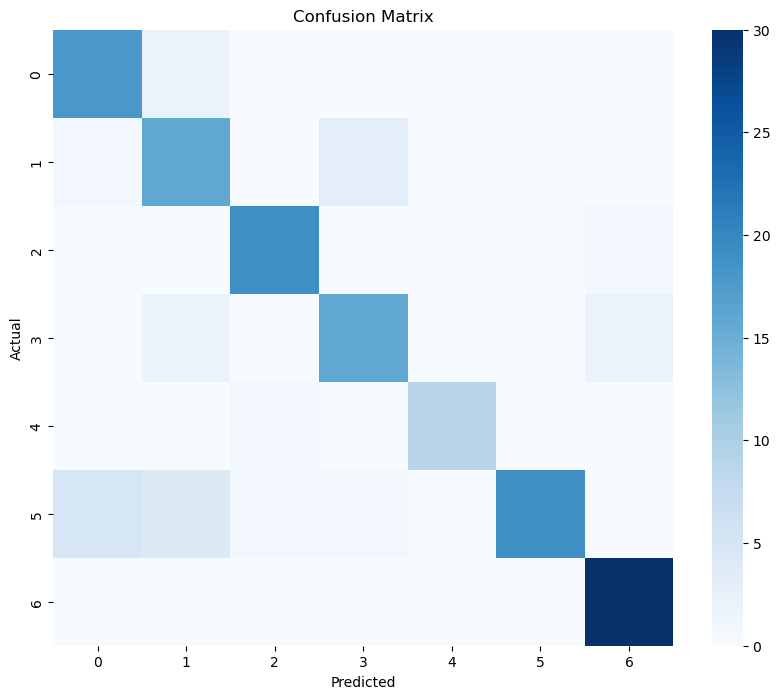

In [25]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [26]:
train_pred = dt_model.predict(X_train)
train_accuracy = accuracy_score(y_train, train_pred)
test_accuracy = accuracy_score(y_test, y_pred)

print("Training Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)

Training Accuracy: 0.8866666666666667
Testing Accuracy: 0.8466666666666667


In [27]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(dt_model, X, y, cv=5)

print("Cross Validation Scores:", scores)
print("Average CV Score:", scores.mean())

Cross Validation Scores: [0.83333333 0.8        0.85       0.875      0.91666667]
Average CV Score: 0.8550000000000001


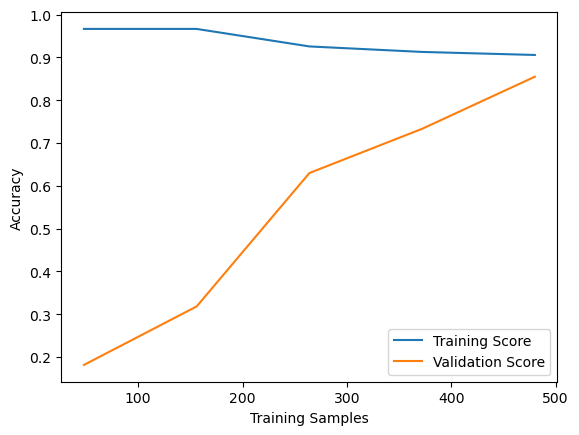

In [28]:
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

train_sizes, train_scores, test_scores = learning_curve(
    dt_model, X, y, cv=5
)

train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

plt.plot(train_sizes, train_mean, label="Training Score")
plt.plot(train_sizes, test_mean, label="Validation Score")

plt.xlabel("Training Samples")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

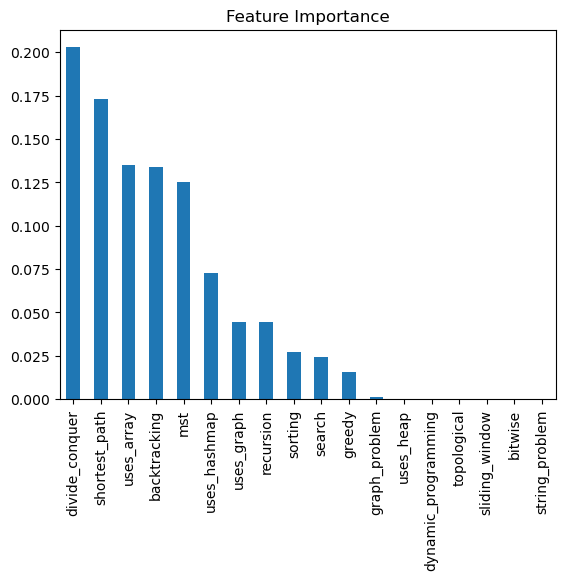

In [29]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.Series(
    dt_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

importance.plot(kind="bar")
plt.title("Feature Importance")
plt.show()

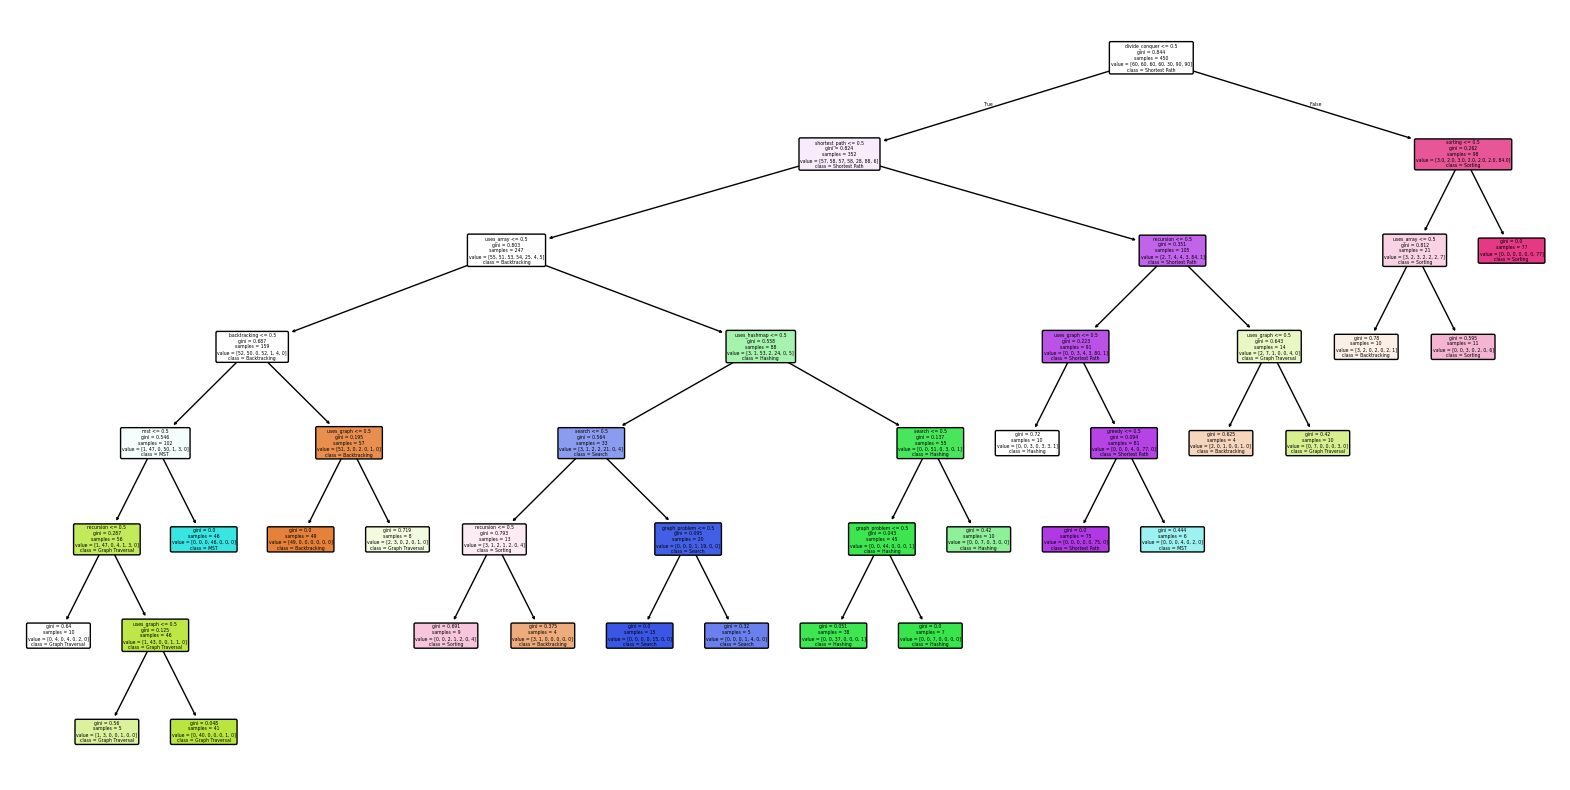

In [30]:

plt.figure(figsize=(20,10))

plot_tree(
    dt_model,
    feature_names=X.columns,
    class_names=le.classes_,
    filled=True,
    rounded=True
)

plt.show()

In [31]:
print(type(y_train[0]))
print(np.unique(y_train))

<class 'numpy.int64'>
[0 1 2 3 4 5 6]


C:\Users\user\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names


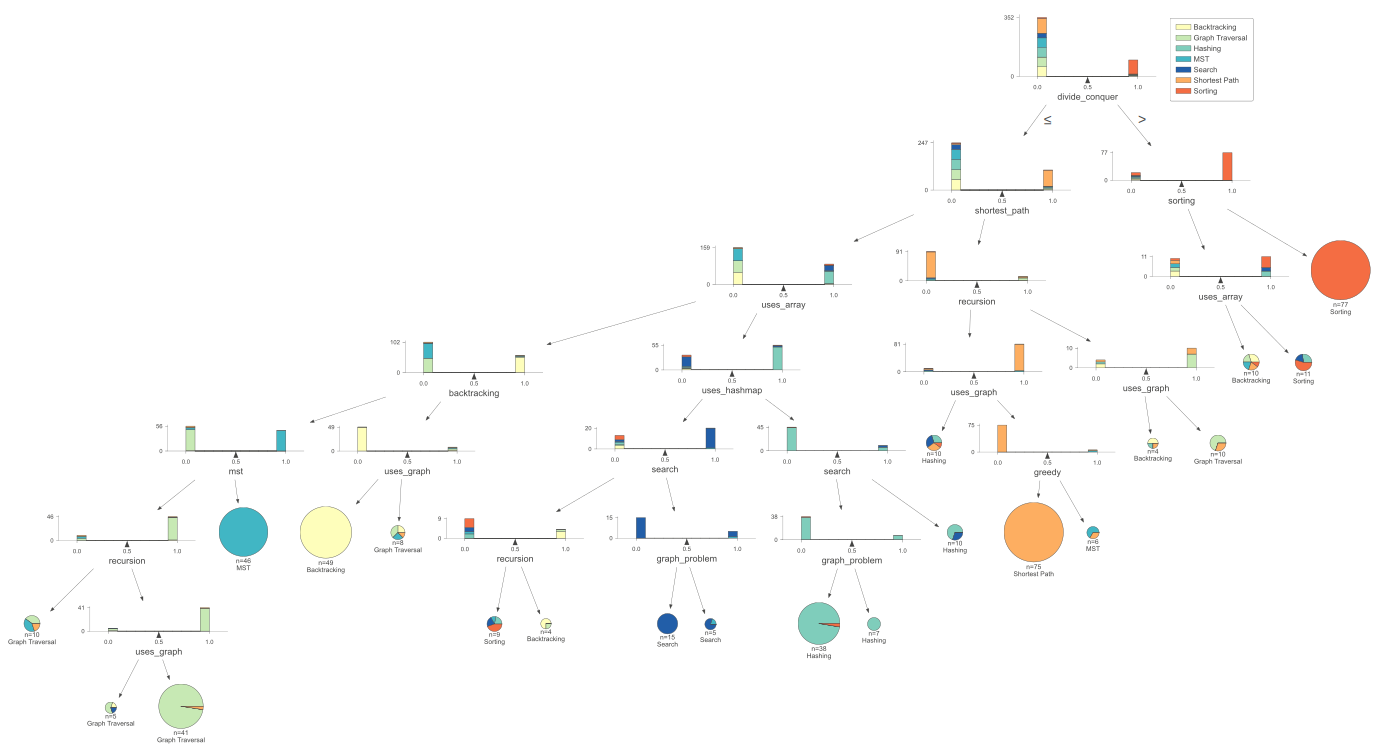

In [32]:
from dtreeviz import model as dtreeviz_model

viz = dtreeviz_model(
    dt_model,
    X_train,
    y_train,
    feature_names=list(X.columns),
    class_names=class_names
)

viz.view()

In [33]:


os.listdir("model")

['.ipynb_checkpoints',
 'decision_tree.pkl',
 'features.pkl',
 'label_encoder.pkl',
 'X_train.pkl',
 'y_train.pkl']

In [34]:
print(X.columns)

Index(['uses_array', 'uses_graph', 'uses_hashmap', 'uses_heap', 'recursion',
       'dynamic_programming', 'divide_conquer', 'shortest_path', 'mst',
       'topological', 'sorting', 'search', 'sliding_window', 'greedy',
       'backtracking', 'bitwise', 'string_problem', 'graph_problem'],
      dtype='object')
